In [60]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import ace_tools_open as tools; 

In [61]:
# List of models again
architectures = ["mobilenetv2", "resnet18", "vgg16", "vit-tiny",
               "efficientnet-b0", "shufflenetv2-0.5x", "regnety-400mf",
               "mnasnet0_5", "convnext-tiny", "ghostnetv2", "tinynet-a"]

def load_metrics_csv(phase, quantization_mode):
    # to store all dfs from the csv files
    dfs = []

    # Load data from all CSVs
    for architecture in architectures:
        # Load CSV in individual dataframe
        path = f"output/metrics/{phase}/{phase}_metrics_{architecture}_fingernail-anemia_base_{quantization_mode}_base.csv"
        # csv_file = glob.glob(path)[0]
        
        df = pd.read_csv(path)

        # Add the model name as a column 
        df["model"] = architecture
        
        # Append to the list of dataframes for all models
        dfs.append(df)

    # Concatenate all data into a single DataFrame
    dfs_all = pd.concat(dfs, ignore_index=True)
    
    return dfs_all

def lineplots(df):
    # Normalize column names
    df.columns = df.columns.str.strip().str.lower()

    # Group by model
    grouped = df.groupby("model")

    # Metrics to plot
    metrics = ['accuracy', 'f1_score', 'auc', 'total_loss']

    # Create subplots: one row per model, one column per metric
    num_models = len(grouped)
    fig, axs = plt.subplots(num_models, len(metrics), figsize=(5 * len(metrics), 4 * num_models), squeeze=False)

    for row_idx, (model_name, model_df) in enumerate(grouped):
        model_df = model_df.sort_values(by=["epoch", "fold"])

        for col_idx, metric in enumerate(metrics):
            ax = axs[row_idx, col_idx]
            
            # Group by epoch and average across folds
            grouped_epoch = model_df.groupby("epoch")[metric].agg(['mean', 'std']).reset_index()

            ax.plot(grouped_epoch["epoch"], grouped_epoch["mean"], label="Mean", color="tab:blue")
            ax.fill_between(grouped_epoch["epoch"],
                            grouped_epoch["mean"] - grouped_epoch["std"],
                            grouped_epoch["mean"] + grouped_epoch["std"],
                            color="tab:blue", alpha=0.2, label="±1 std")

            ax.set_title(f"{model_name} - {metric}")
            ax.set_xlabel("Epoch")
            ax.set_ylabel(metric)
            ax.legend()
            ax.grid(True)

    plt.tight_layout()
    plt.show()

def summary_table(df):
    # Define the metrics to include
    metrics = [
        'total_loss', 'cross_entropy_loss', 'accuracy', 'precision', 'recall',
        'f1_score', 'auc', 'r2_score', 'mae_loss', 'mse_loss'
    ]

    # Compute mean and std per model
    mean_df = df.groupby('model')[metrics].mean()
    std_df = df.groupby('model')[metrics].std()

    # Combine as "mean ± std" string format
    summary_df = pd.DataFrame(index=mean_df.index)

    for metric in metrics:
        summary_df[metric] = mean_df[metric].round(4).astype(str) + ' ± ' + std_df[metric].round(4).astype(str)

    # Reset index to include model as a column
    summary_df = summary_df.reset_index()

    # Show the result
    tools.display_dataframe_to_user(name="Model Summary (mean ± std)", dataframe=summary_df)

In [62]:
train_metrics = load_metrics_csv("training", "base")
val_metrics = load_metrics_csv("validation", "base")

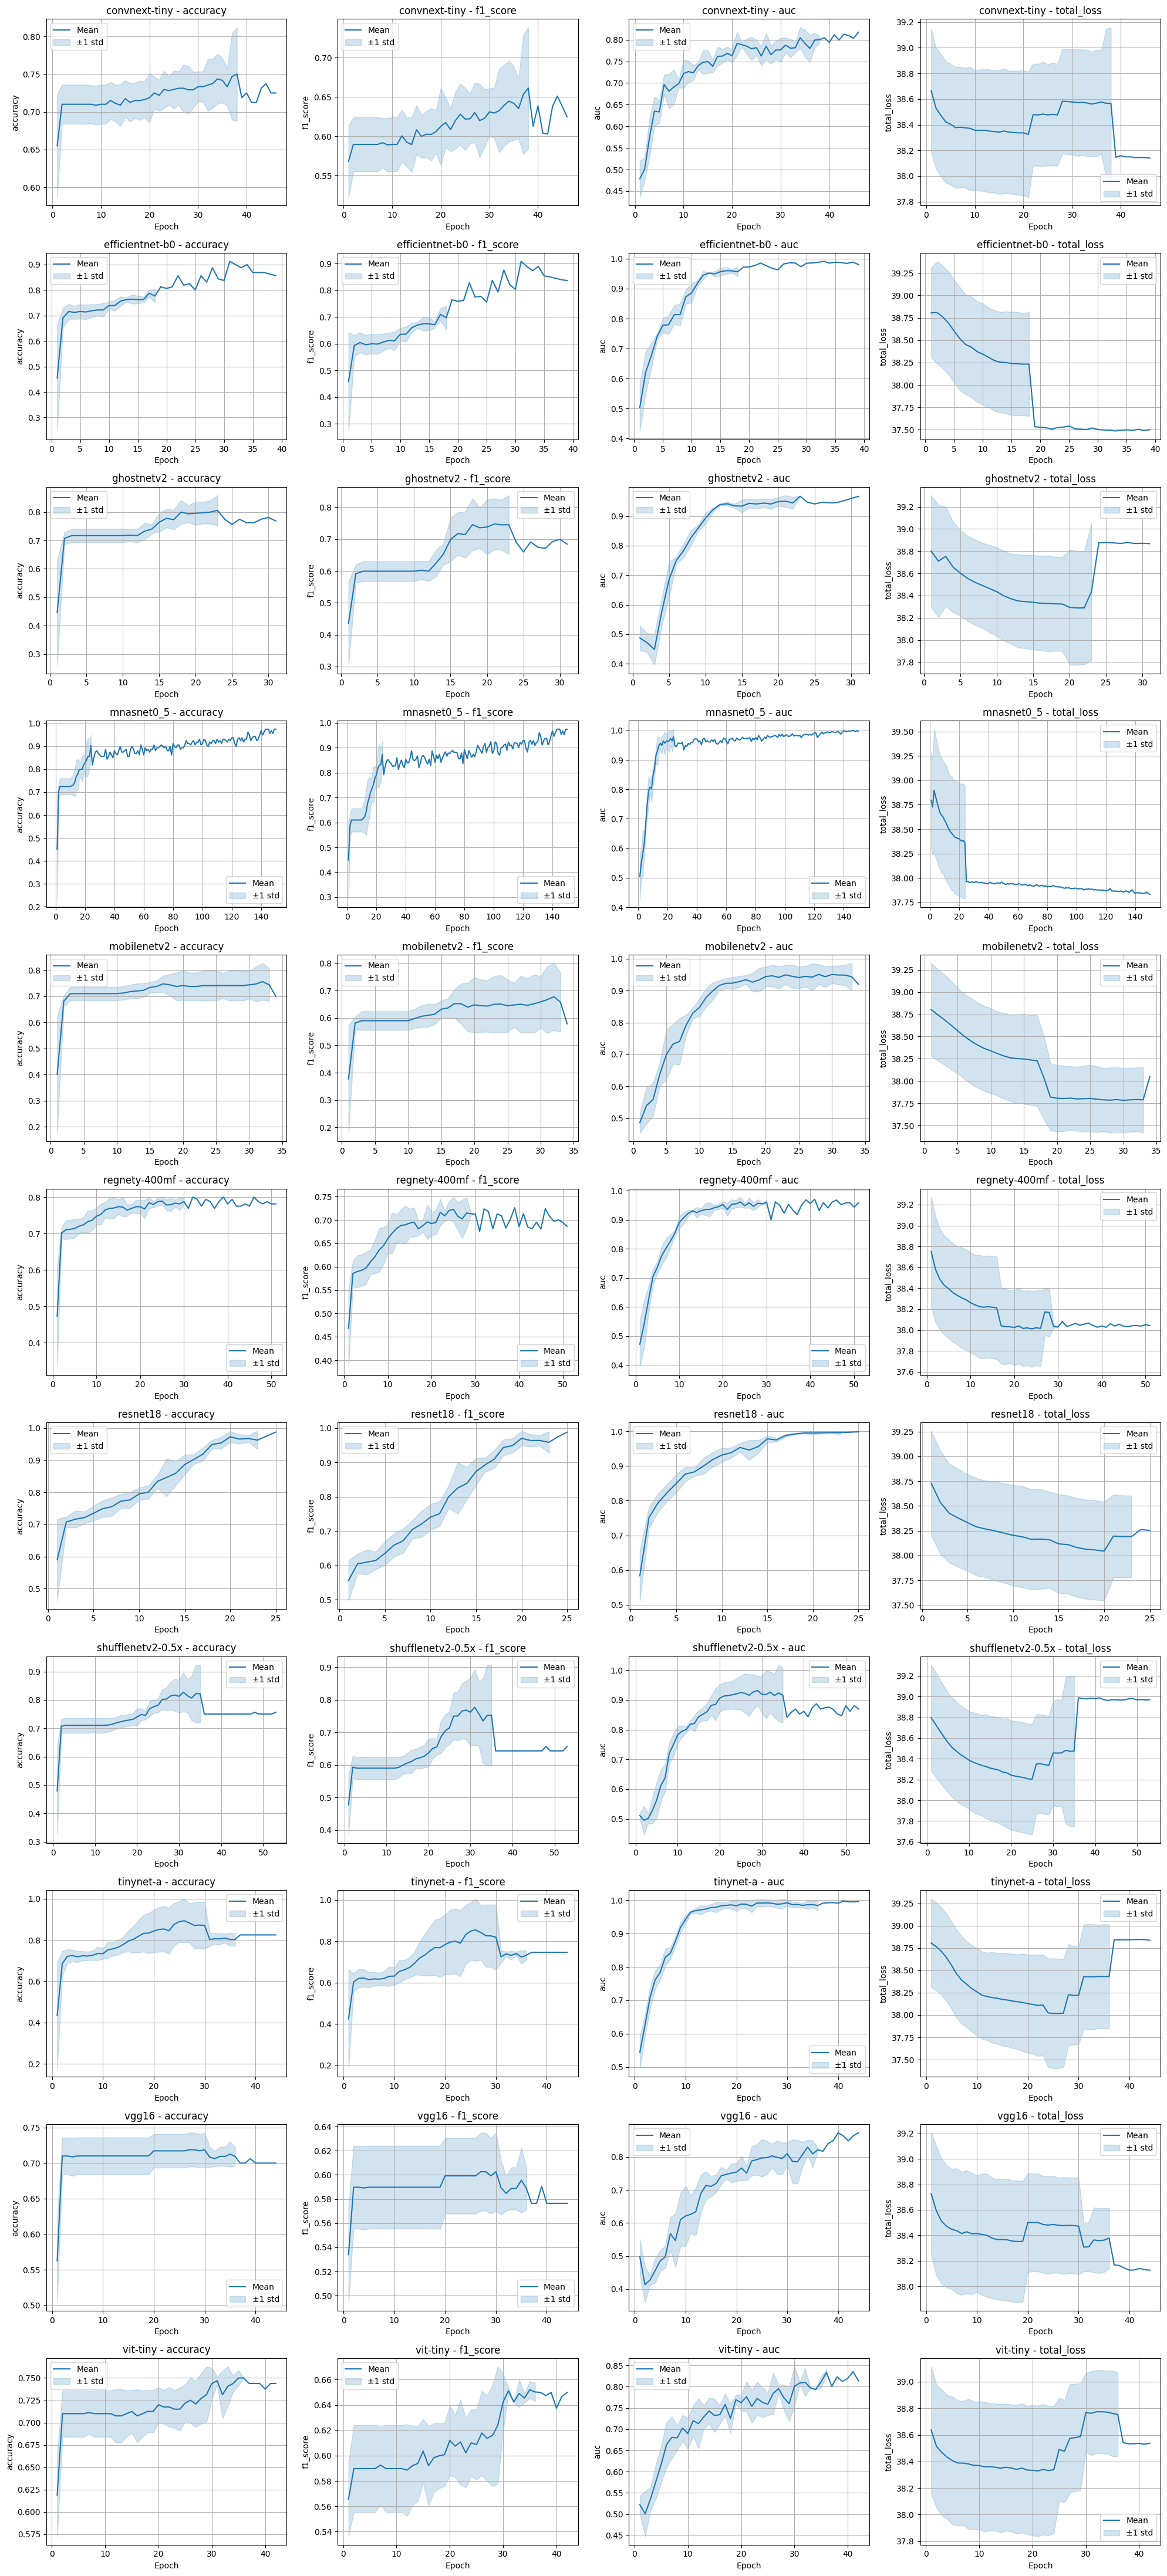

In [63]:
lineplots(train_metrics)

In [65]:
summary_table(train_metrics)

Model Summary (mean ± std)


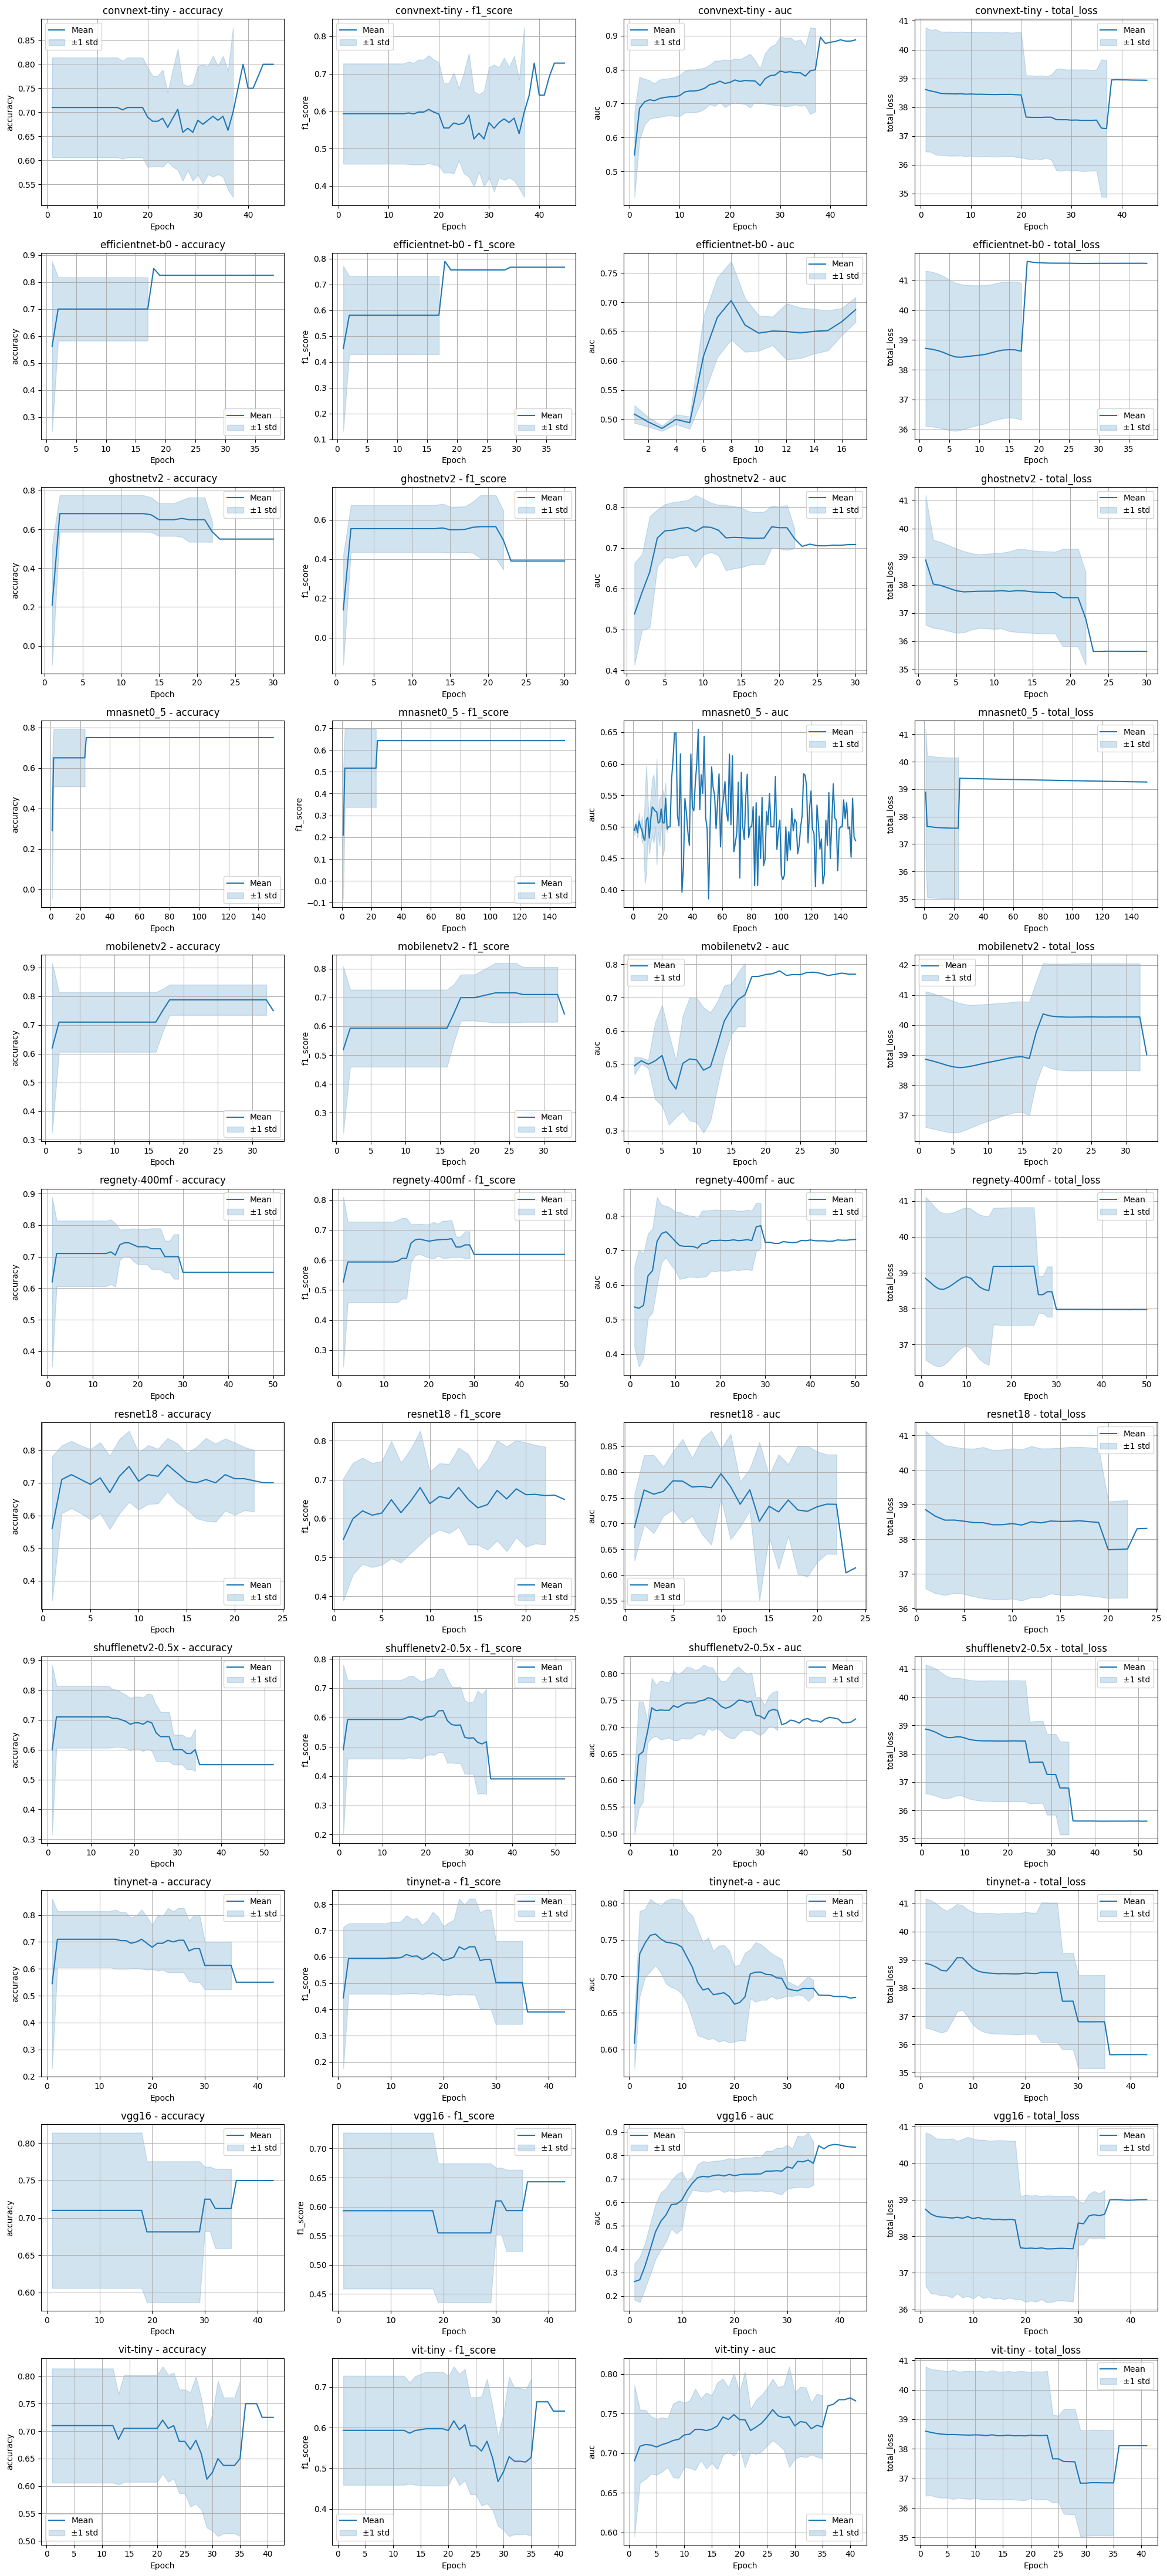

In [ ]:
lineplots(val_metrics)

In [66]:
summary_table(val_metrics)

Model Summary (mean ± std)


In [68]:
# List of models again
architectures = ["mobilenetv2", "resnet18", "vit-tiny", "shufflenetv2-0.5x", "regnety-400mf",
               "mnasnet0_5", "ghostnetv2"]

train_qat_metrics = load_metrics_csv("training", "qat")
val_qat_metrics = load_metrics_csv("validation", "qat")

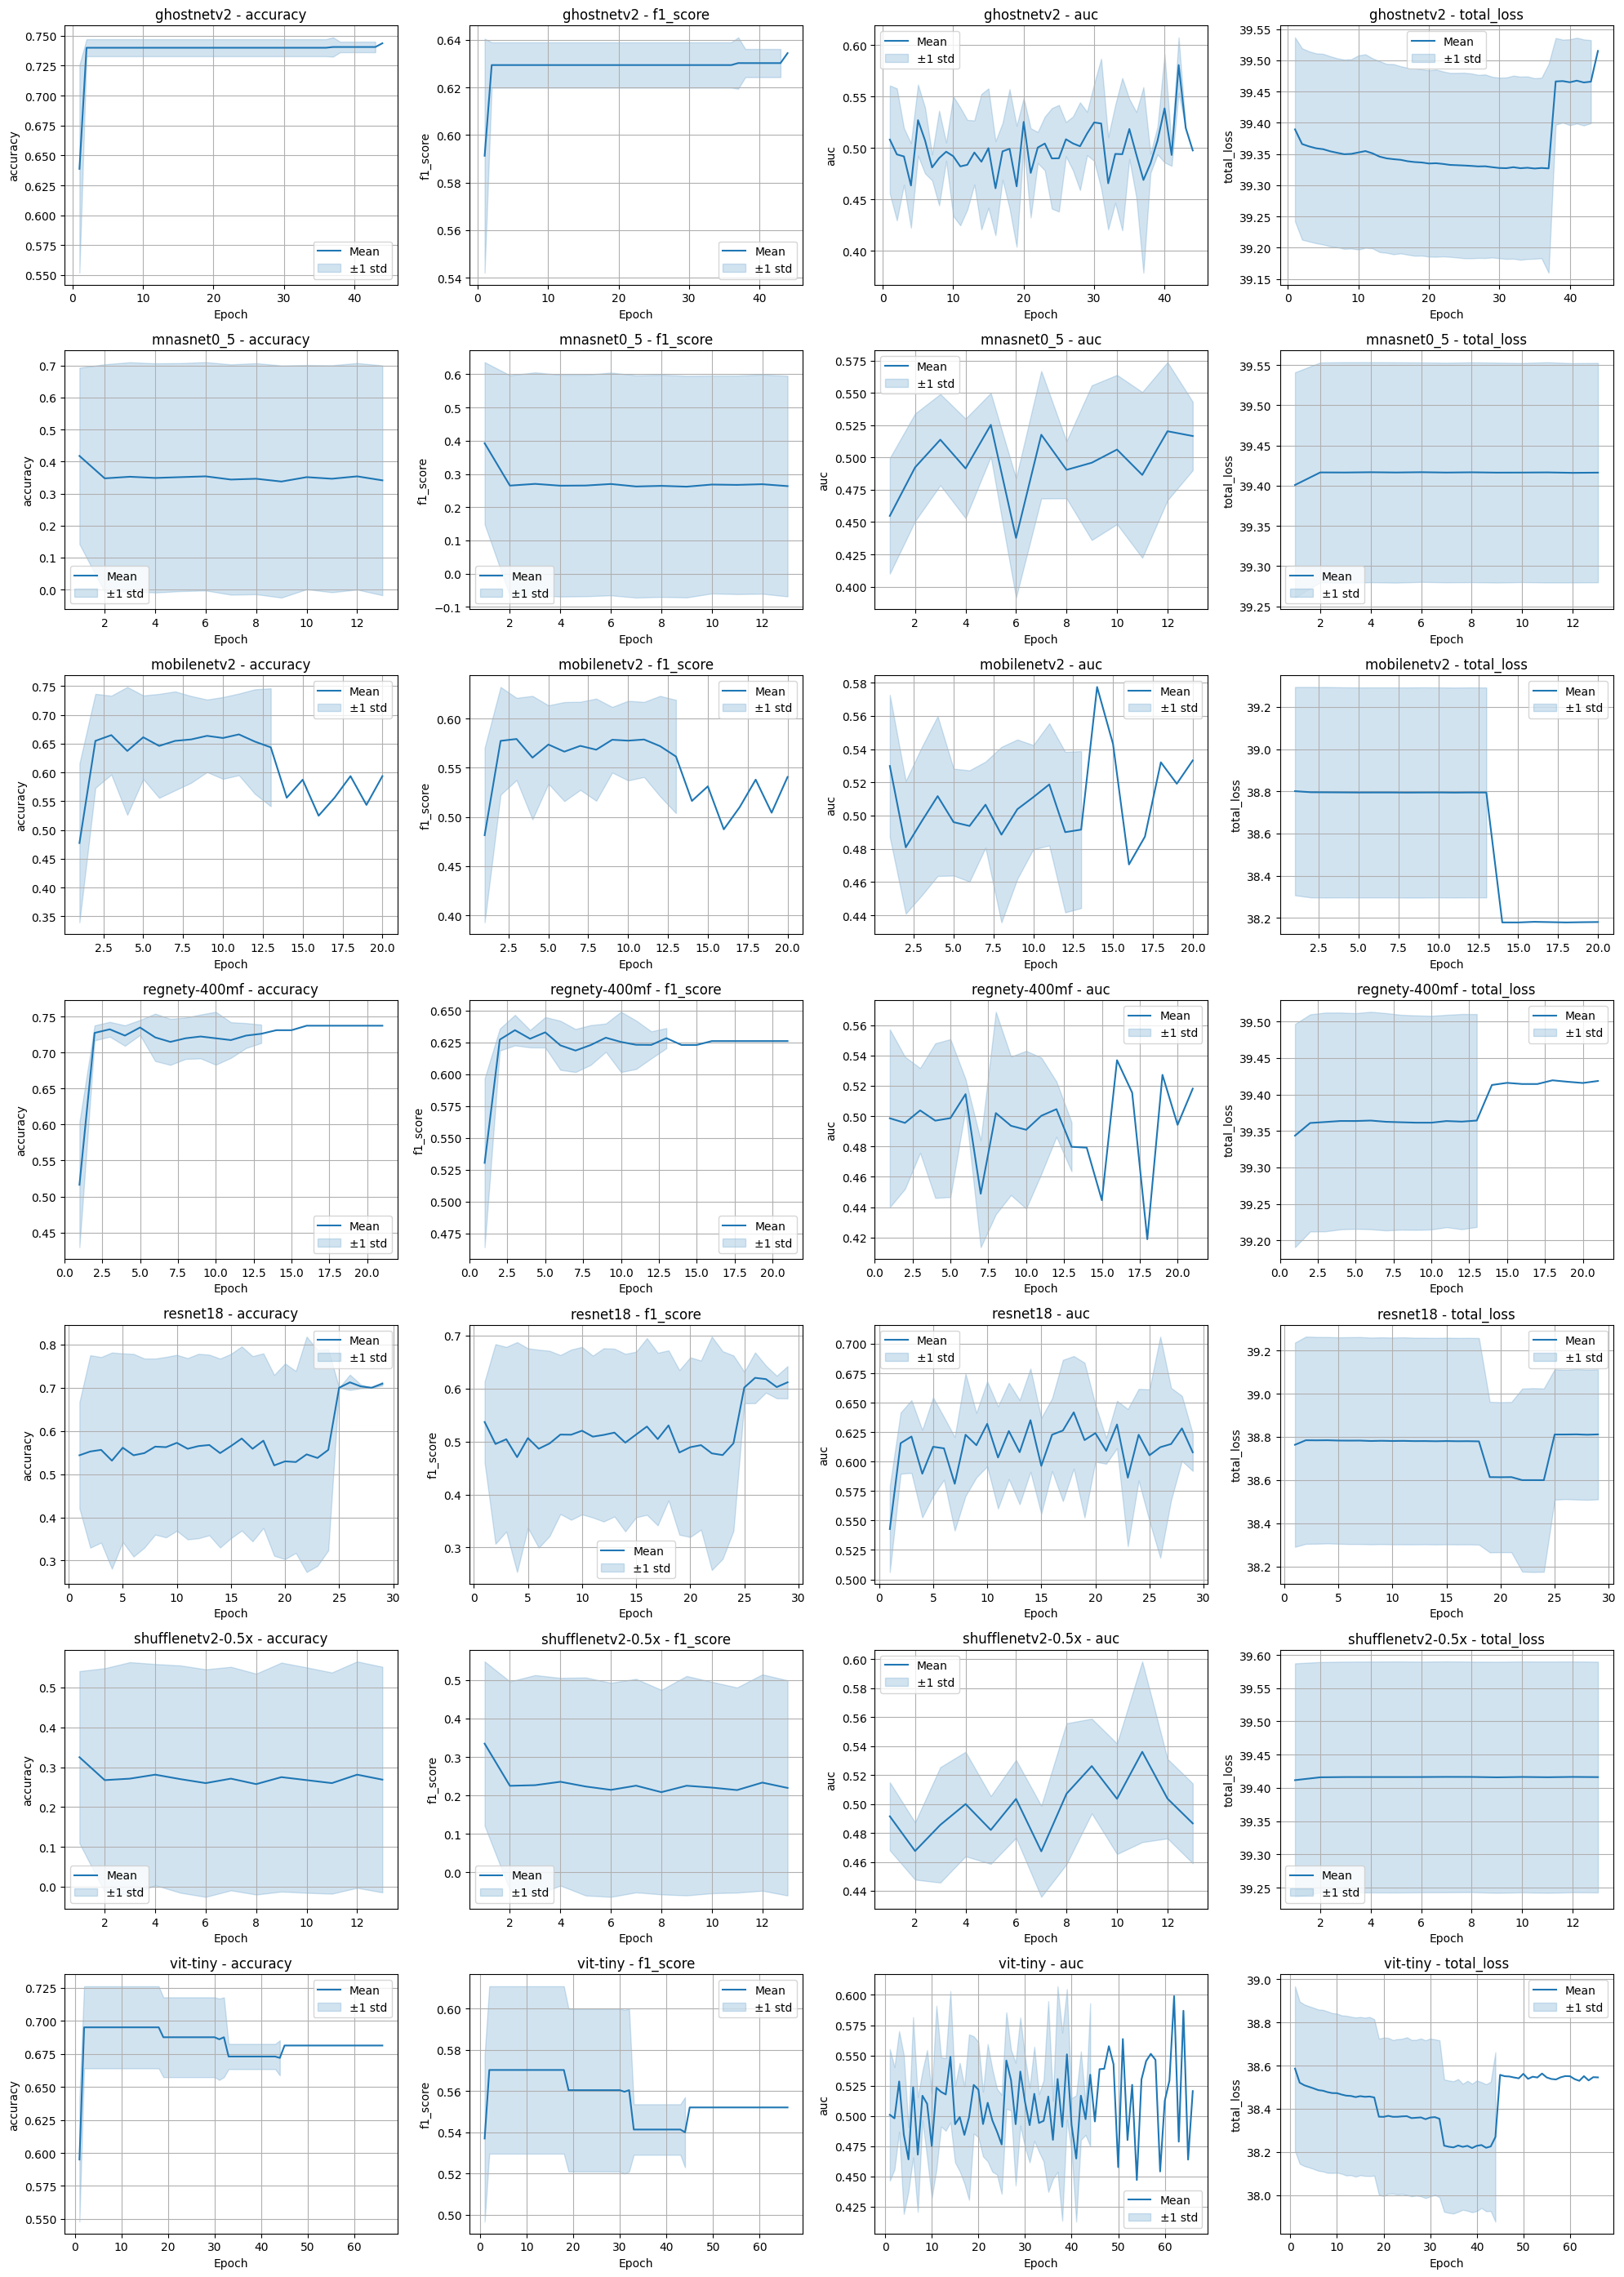

In [69]:
lineplots(train_qat_metrics)

In [70]:
summary_table(train_qat_metrics)

Model Summary (mean ± std)


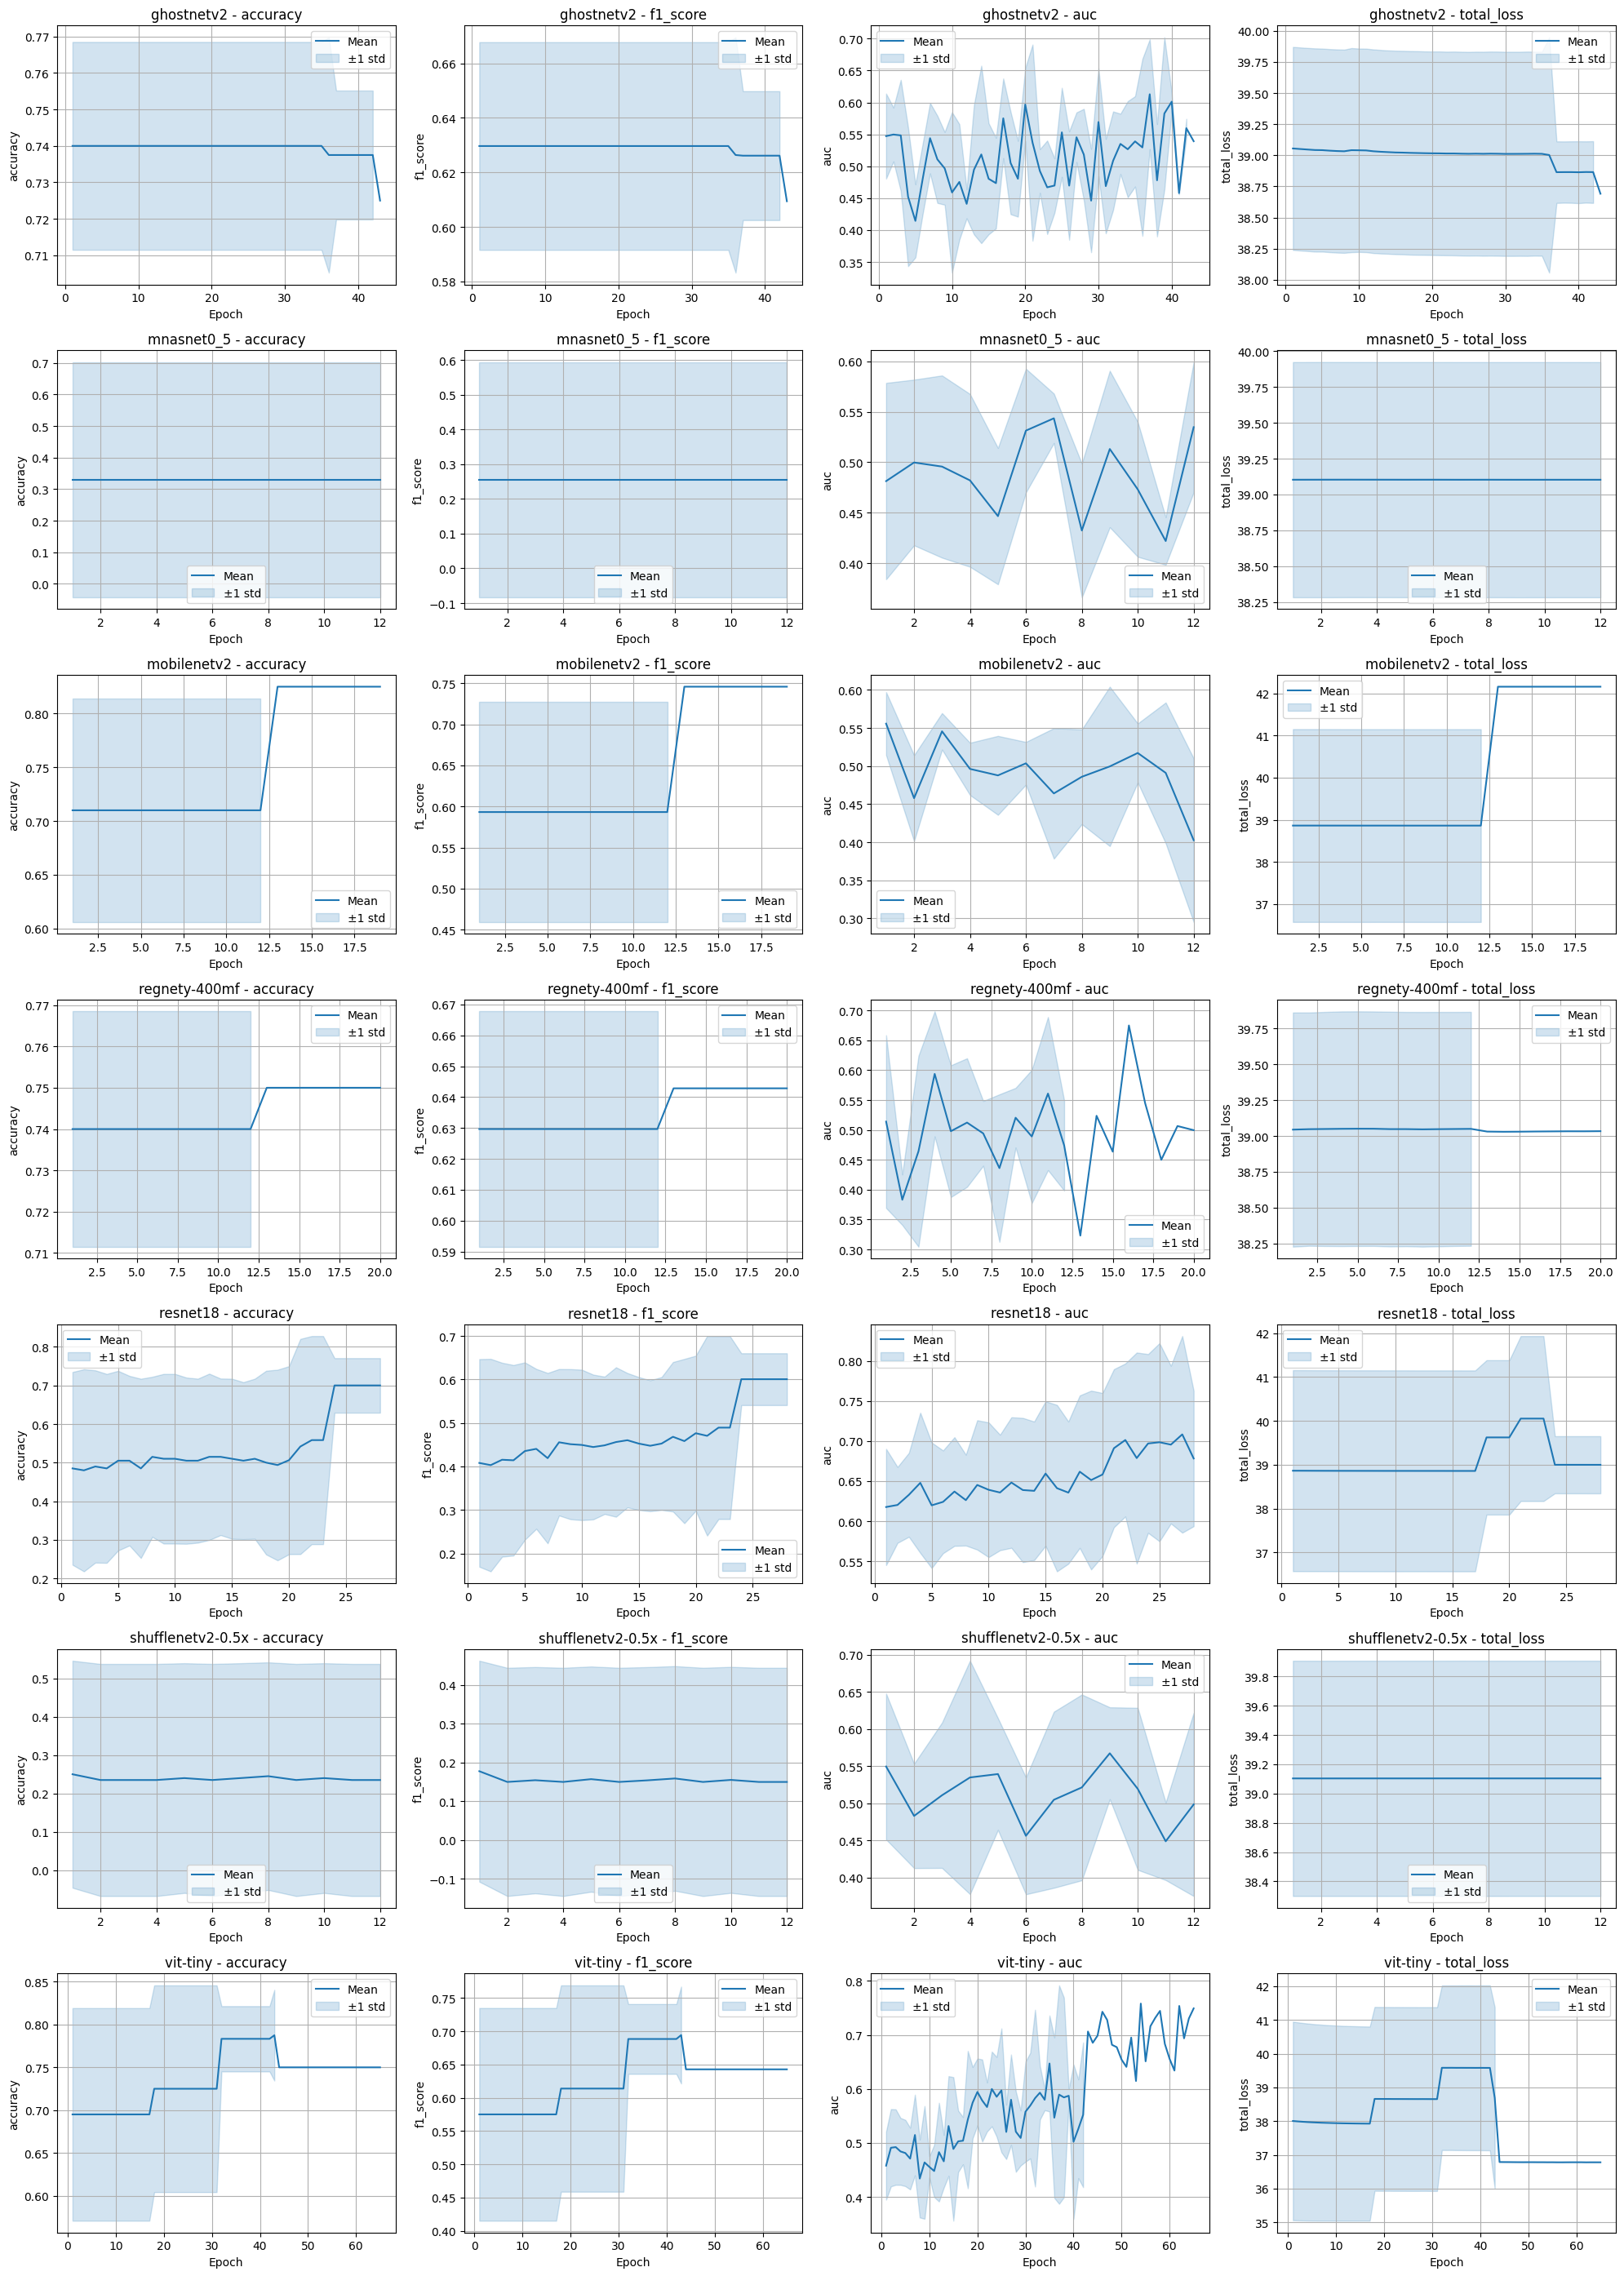

In [71]:
lineplots(val_qat_metrics)

In [72]:
summary_table(val_qat_metrics)

Model Summary (mean ± std)


In [85]:
import os

def get_model_weight_sizes(phase, quantization_mode, architectures, weights_dir="output/weights/"):
    weight_sizes = []

    for architecture in architectures:
        # Construct the expected filename
        filename = f"model_best_loss_{architecture}_fingernail-anemia_base_{quantization_mode}_base.pth"
        path = os.path.join(weights_dir, filename)
        
        if os.path.exists(path):
            size_mb = os.path.getsize(path) / (1024 * 1024)
            weight_sizes.append({"model": architecture, "size_MB": round(size_mb, 2)})
        else:
            # print(f"[Warning] File not found: {path}")
            weight_sizes.append({"model": architecture, "size_MB": 0})

    # Return as a DataFrame
    return pd.DataFrame(weight_sizes)


In [86]:
architectures = [
    "mobilenetv2", "resnet18", "mnasnet0_5", "ghostnetv2", 
    "tinynet-a", "regnety-400mf", "shufflenetv2-0.5x", 
    "convnext-tiny", "efficientnet-b0", "vit-tiny", "vgg16"
]

model_sizes_df = get_model_weight_sizes(phase="training", quantization_mode="base", architectures=architectures)
display(model_sizes_df)

,model,size_MB
0,mobilenetv2,20.23
1,resnet18,86.69
2,mnasnet0_5,10.31
3,ghostnetv2,41.07
4,tinynet-a,40.93
5,regnety-400mf,31.45
6,shufflenetv2-0.5x,5.20
7,convnext-tiny,214.15
8,efficientnet-b0,33.96
9,vit-tiny,42.91


In [87]:
model_sizes_df = get_model_weight_sizes(phase="training", quantization_mode="qat", architectures=architectures)
display(model_sizes_df)

,model,size_MB
0,mobilenetv2,20.22
1,resnet18,86.71
2,mnasnet0_5,10.31
3,ghostnetv2,41.31
4,tinynet-a,0.00
5,regnety-400mf,31.67
6,shufflenetv2-0.5x,5.21
7,convnext-tiny,0.00
8,efficientnet-b0,0.00
9,vit-tiny,43.62
